# Notebook 02 — Análise Exploratória

**Projeto:** Mapa da Inseminação Artificial no Brasil  
**Autor:** Mateus Martins — Médico Veterinário

Aqui é onde os dados viram história. Vou gerar 8 gráficos que contam o panorama
da inseminação artificial no Brasil — de onde veio, onde está, e pra onde pode ir.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import os
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

# Paleta de cores consistente
AZUL = '#2E75B6'
VERDE = '#548235'
VERMELHO = '#C0504D'
AMARELO = '#E6A817'
CINZA = '#7F7F7F'
LARANJA = '#ED7D31'

CORES_REGIAO = {
    'Norte': '#E6A817',
    'Nordeste': '#C0504D',
    'Sudeste': '#2E75B6',
    'Sul': '#548235',
    'Centro-Oeste': '#ED7D31'
}

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['figure.dpi'] = 150

os.makedirs('plots', exist_ok=True)
print('Setup OK')

Setup OK


In [2]:
# Carregar datasets gerados no notebook 01
df = pd.read_csv('data/processed/dataset_ia_brasil.csv')
asbia_brasil = pd.read_csv('data/raw/asbia_dados_compilados.csv')

print(f'Dataset principal: {df.shape}')
print(f'Série temporal ASBIA: {asbia_brasil.shape}')
df.head()

Dataset principal: (27, 10)
Série temporal ASBIA: (15, 6)


,sigla_uf,uf,rebanho,regiao,pct_femeas_inseminadas_corte,pct_femeas_inseminadas_leite,femeas_estimadas,femeas_inseminadas_est,femeas_nao_inseminadas,potencial_doses
0,MT,Mato Grosso,34245000,Centro-Oeste,24.3,6.0,18834750,4576844,14257906,4277371
1,GO,Goiás,24015000,Centro-Oeste,28.5,10.0,13208250,3764351,9443899,2833169
2,PA,Pará,23580000,Norte,11.8,2.5,12969000,1530342,11438658,3431597
3,MG,Minas Gerais,23105000,Sudeste,22.0,14.0,12707750,2795705,9912045,2973613
4,MS,Mato Grosso do Sul,20150000,Centro-Oeste,26.8,8.5,11082500,2970110,8112390,2433717


## Gráfico 1 — Evolução da IATF no Brasil (2010-2024)

Esse é o gráfico que mostra a história da IATF no Brasil. De 6 milhões de protocolos 
em 2010 para 23 milhões em 2024 — quase 4x. Mas o que mais chama atenção é como 
a curva acompanha o preço da arroba. Quando o boi paga bem, o pecuarista investe 
em genética.

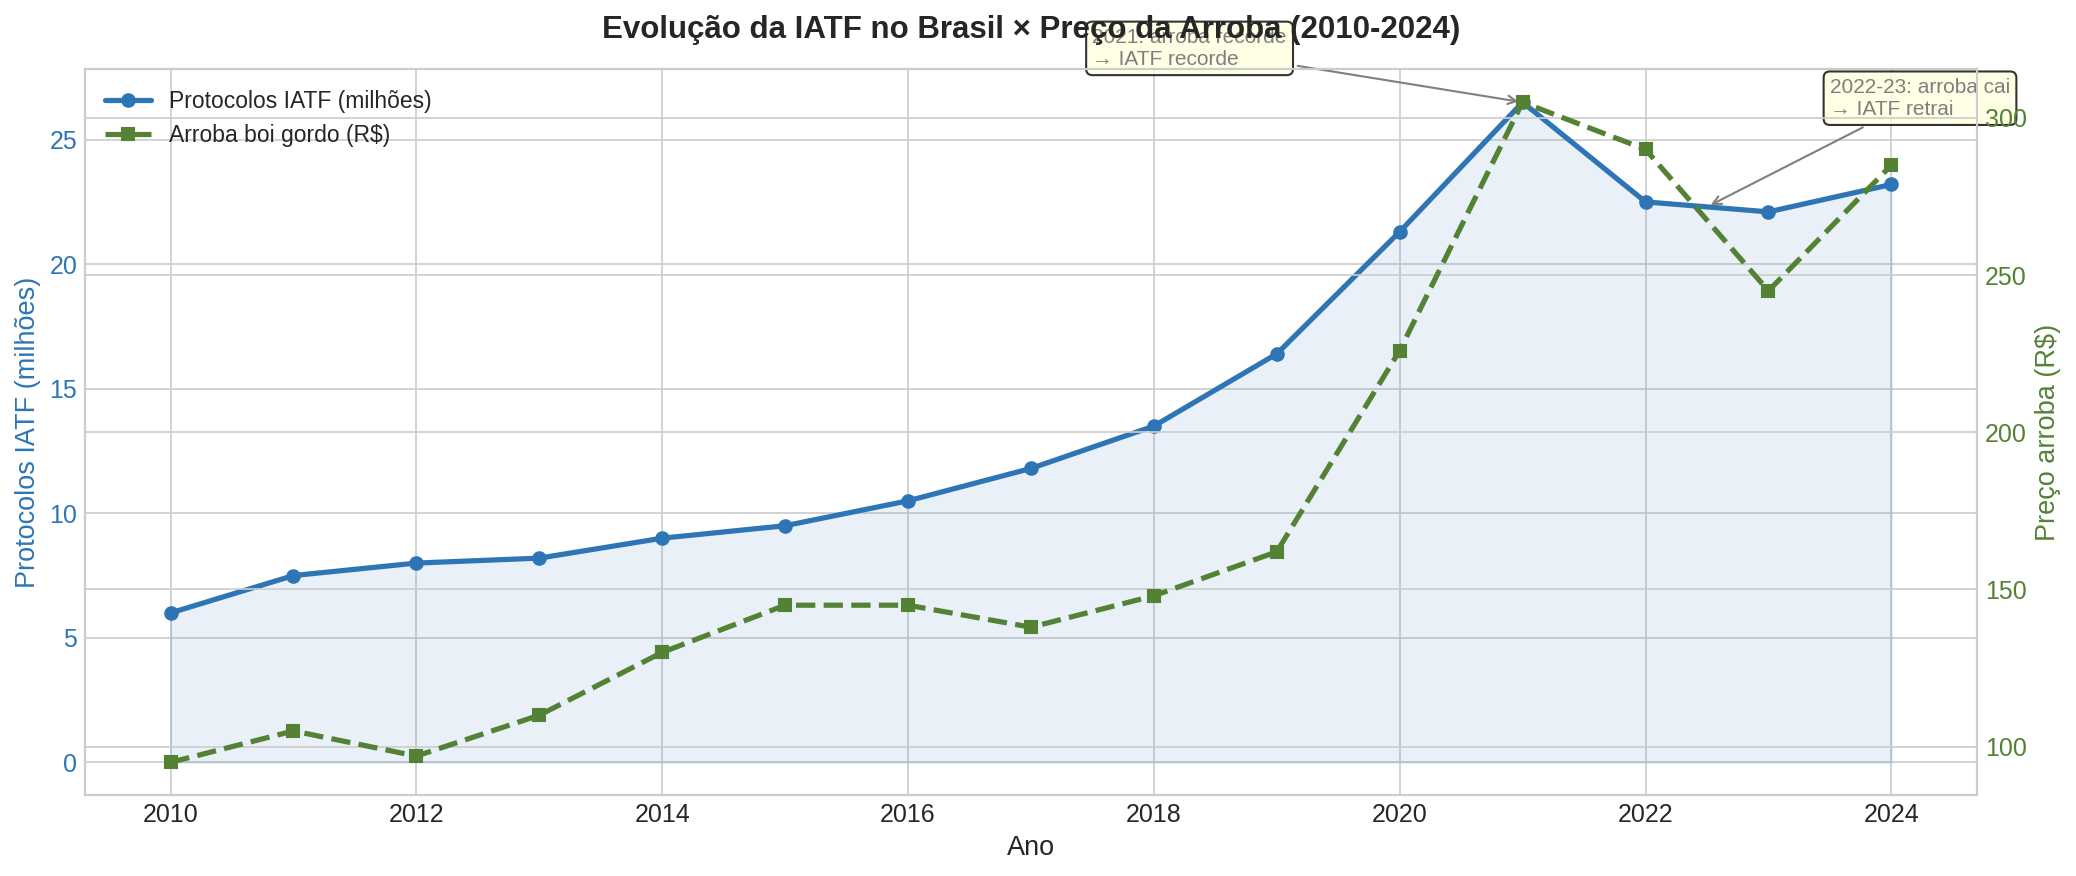

Salvo: plots/01_evolucao_iatf_brasil.png


In [3]:
fig, ax1 = plt.subplots(figsize=(14, 6))

# Eixo esquerdo: protocolos IATF
ax1.plot(asbia_brasil['ano'], asbia_brasil['protocolos_iatf_milhoes'], 
         color=AZUL, linewidth=2.5, marker='o', markersize=6, label='Protocolos IATF (milhões)')
ax1.fill_between(asbia_brasil['ano'], asbia_brasil['protocolos_iatf_milhoes'], alpha=0.1, color=AZUL)
ax1.set_xlabel('Ano', fontsize=13)
ax1.set_ylabel('Protocolos IATF (milhões)', color=AZUL, fontsize=13)
ax1.tick_params(axis='y', labelcolor=AZUL)

# Eixo direito: preço da arroba
ax2 = ax1.twinx()
ax2.plot(asbia_brasil['ano'], asbia_brasil['preco_arroba_media_anual'],
         color=VERDE, linewidth=2.5, marker='s', markersize=6, linestyle='--', label='Arroba boi gordo (R$)')
ax2.set_ylabel('Preço arroba (R$)', color=VERDE, fontsize=13)
ax2.tick_params(axis='y', labelcolor=VERDE)

# Anotações
ax1.annotate('2021: arroba recorde\n→ IATF recorde', xy=(2021, 26.5), xytext=(2017.5, 28),
            arrowprops=dict(arrowstyle='->', color=CINZA), fontsize=10, color=CINZA,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

ax1.annotate('2022-23: arroba cai\n→ IATF retrai', xy=(2022.5, 22.3), xytext=(2023.5, 26),
            arrowprops=dict(arrowstyle='->', color=CINZA), fontsize=10, color=CINZA,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

ax1.set_title('Evolução da IATF no Brasil × Preço da Arroba (2010-2024)', fontsize=15, fontweight='bold', pad=15)

# Legenda combinada
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=11)

plt.tight_layout()
plt.savefig('plots/01_evolucao_iatf_brasil.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvo: plots/01_evolucao_iatf_brasil.png')

## Gráfico 2 — % de Fêmeas Inseminadas por Região

O Sul lidera, o Norte e Nordeste ficam abaixo da média. Mas o Nordeste é 
heterogêneo — Alagoas puxa a média pra cima enquanto Piauí e Maranhão a derrubam.

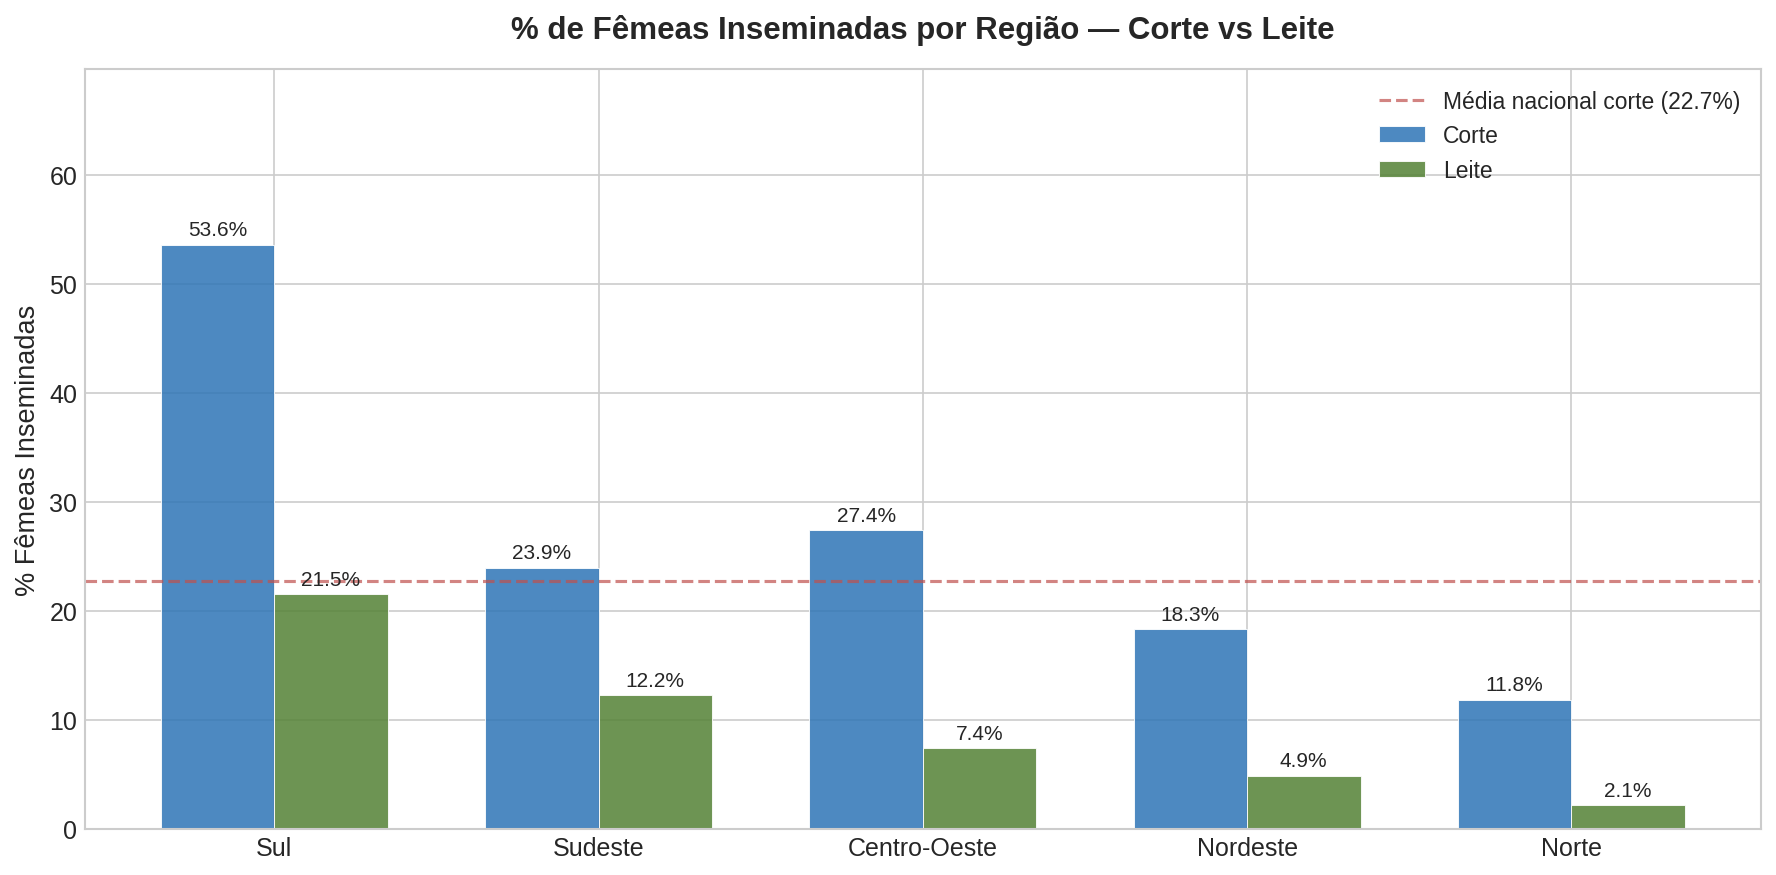

Salvo: plots/02_inseminacao_por_regiao.png


In [4]:
# Calcular médias por região (corte e leite)
regioes_order = ['Sul', 'Sudeste', 'Centro-Oeste', 'Nordeste', 'Norte']
media_corte = df.groupby('regiao')['pct_femeas_inseminadas_corte'].mean()
media_leite = df.groupby('regiao')['pct_femeas_inseminadas_leite'].mean()

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(regioes_order))
width = 0.35

bars1 = ax.bar(x - width/2, [media_corte[r] for r in regioes_order], width, 
               label='Corte', color=AZUL, alpha=0.85, edgecolor='white', linewidth=0.5)
bars2 = ax.bar(x + width/2, [media_leite[r] for r in regioes_order], width,
               label='Leite', color=VERDE, alpha=0.85, edgecolor='white', linewidth=0.5)

# Média nacional
media_nac = df['pct_femeas_inseminadas_corte'].mean()
ax.axhline(y=media_nac, color=VERMELHO, linestyle='--', linewidth=1.5, alpha=0.7,
           label=f'Média nacional corte ({media_nac:.1f}%)')

# Labels nas barras
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=10)

ax.set_title('% de Fêmeas Inseminadas por Região — Corte vs Leite', fontsize=15, fontweight='bold', pad=15)
ax.set_ylabel('% Fêmeas Inseminadas', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(regioes_order, fontsize=12)
ax.legend(fontsize=11)
ax.set_ylim(0, max(media_corte.max(), media_leite.max()) * 1.3)

plt.tight_layout()
plt.savefig('plots/02_inseminacao_por_regiao.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvo: plots/02_inseminacao_por_regiao.png')

## Gráfico 3 — Ranking de UFs: % de Fêmeas Inseminadas

O dado mais surpreendente desse projeto: **Alagoas com 79,5%** — segundo lugar 
nacional, atrás apenas de Santa Catarina. Um estado pequeno do Nordeste com 
adoção altíssima. Pra um veterinário, isso é contraintuitivo.